# KeyVR dataset explorer

In [14]:
%matplotlib inline
import torchvision
import matplotlib.pyplot as plt
from IPython.display import HTML
from matplotlib import animation

def display_video(video_tensor):
    """
    Display video from PyTorch tensor with shape (frames, height, width, channels)
    Video values should be in range 0-255
    
    Parameters:
        video_tensor: PyTorch tensor of shape (frames, height, width, channels)
    """
    video_normalized = video_tensor.cpu().numpy() / 255.0
    fig = plt.figure(figsize=(8, 4))
    im = plt.imshow(video_normalized[0])
    plt.axis('off')
    
    def animate(i):
        im.set_data(video_normalized[i])
        return [im]
    
    anim = animation.FuncAnimation(
        fig, 
        animate, 
        frames=len(video_normalized),
        interval=500,  # Time between frames in milliseconds
        blit=True
    )
    
    return HTML(anim.to_jshtml())

In [6]:
from lightning_utils.lm_dataset import KeyClfStreamDataset

## Create a dataset from a video and the skeletons of every frame extracted by MediaPipe

For example, we select the first video in KeyVR dataset. We need to specify the path to:
- video: contains raw frames
- label: contains the frame numbers of keystrokes
- landmark: contains the skeletons of frames
- delay: this is the delay between the recorded frame and the actual frame number of the keystroke. This happens because the ip camera need some time to send the image to the computer.

Note: If you're using Kaggle, you need to change the path to the dataset path of the notebook.

In [16]:
idx = 0
dataset = "KeyVR"
video_path=f'datasets/{dataset}/videos/video_{idx}'
classes_path=f'datasets/{dataset}/clf.json'
label_path=f'datasets/{dataset}/labels/video_{idx}.csv'
landmark_path=f'datasets/{dataset}/landmarks/video_{idx}.pt'
delay = 0
clf_ds = KeyClfStreamDataset(
    video_path=video_path,
    label_path=label_path,
    classes_path=classes_path,
    landmark_path=landmark_path,
    delay=delay,
    f_before=3,
    f_after=4
)

In [20]:
clf_ds.get_class_counts()

,label,count
0,a,25
1,b,6
2,c,11
3,d,13
4,e,47
5,f,10
6,g,5
7,h,14
8,i,17
9,j,2


## Display a video with skeleton 

In [21]:
sample, label = clf_ds.create_segment(idx=1, mode="skeleton", format=None)
label

'o'

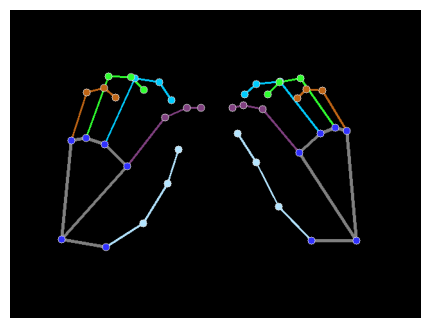

In [22]:
display_video(sample)